<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-04-04 20:46:36--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.1’

survey-data.csv.1   100%[===================>] 152.13M  48.7MB/s    in 3.1s    

2026-04-04 20:46:41 (48.7 MB/s) - ‘survey-data.csv.1’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

df = pd.read_csv('survey-data.csv')
print("Dataset carregado:", df.shape)

Dataset carregado: (19222, 114)


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [4]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [5]:
conn = sqlite3.connect('survey-data.sqlite')
df.to_sql('main', conn, if_exists='replace', index=False)
print("Banco criado e conectado!")

Banco criado e conectado!


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [6]:
df_check = pd.read_sql_query("SELECT * FROM main LIMIT 5", conn)
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [7]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df_count = pd.read_sql_query(QUERY, conn)
df_count.head()


,COUNT(*)
0,19222


## Demo: Listing All Tables


To view the names of all tables in the database:


In [8]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [9]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,NaN,1
1,18-24 years old,3870
2,25-34 years old,7196
3,35-44 years old,4533
4,45-54 years old,1888
5,55-64 years old,729
6,65 years or older,234
7,Prefer not to say,88
8,Under 18 years old,683


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [10]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


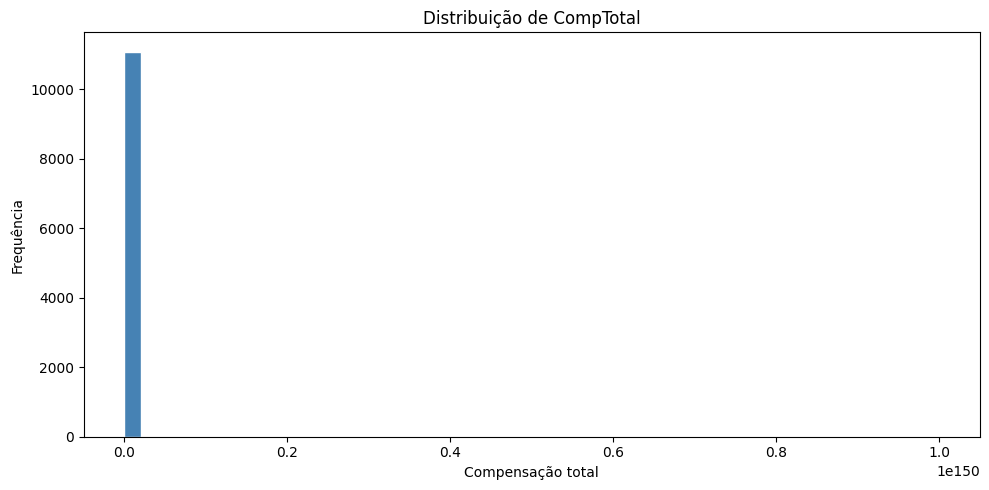

In [11]:
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"
df_comp = pd.read_sql_query(QUERY, conn)
df_comp['CompTotal'] = pd.to_numeric(df_comp['CompTotal'], errors='coerce').dropna()

plt.figure(figsize=(10, 5))
plt.hist(df_comp['CompTotal'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Distribuição de CompTotal')
plt.xlabel('Compensação total')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

**Box Plots**

Plot a box plot of Age.


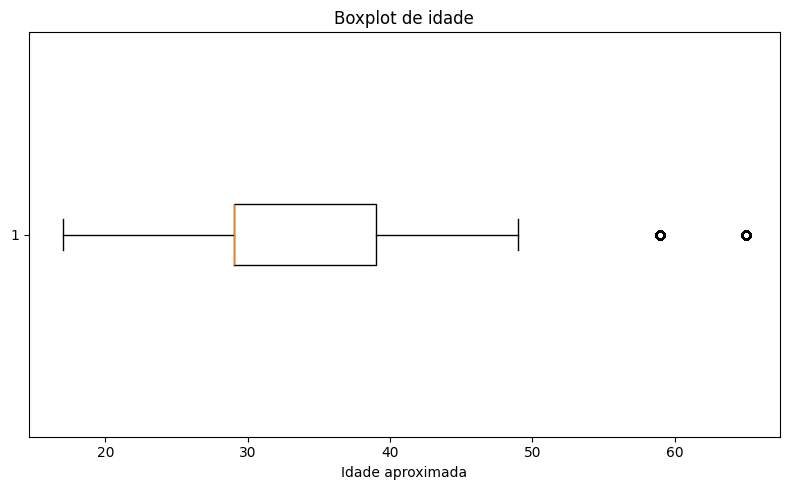

In [12]:
QUERY = "SELECT Age FROM main WHERE Age IS NOT NULL"
df_age = pd.read_sql_query(QUERY, conn)

age_map = {
    'Under 18 years old': 17, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 65
}
df_age['Age_num'] = df_age['Age'].map(age_map)

plt.figure(figsize=(8, 5))
plt.boxplot(df_age['Age_num'].dropna(), vert=False)
plt.title('Boxplot de idade')
plt.xlabel('Idade aproximada')
plt.tight_layout()
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


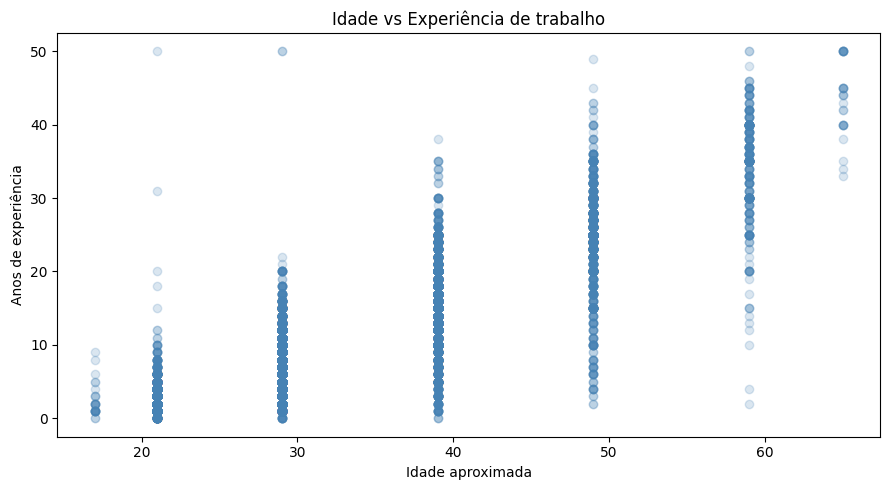

In [13]:
QUERY = "SELECT Age, WorkExp FROM main WHERE Age IS NOT NULL AND WorkExp IS NOT NULL"
df_scatter = pd.read_sql_query(QUERY, conn)
df_scatter['Age_num'] = df_scatter['Age'].map(age_map)
df_scatter['WorkExp'] = pd.to_numeric(df_scatter['WorkExp'], errors='coerce')

plt.figure(figsize=(9, 5))
plt.scatter(df_scatter['Age_num'], df_scatter['WorkExp'], alpha=0.2, color='steelblue')
plt.title('Idade vs Experiência de trabalho')
plt.xlabel('Idade aproximada')
plt.ylabel('Anos de experiência')
plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [15]:
QUERY = "SELECT TimeSearching, Frustration FROM main LIMIT 20"
df_test = pd.read_sql_query(QUERY, conn)
print(df_test)

           TimeSearching                                        Frustration
0                    NaN                                                NaN
1                    NaN                                                NaN
2                    NaN                                                NaN
3                    NaN                                                NaN
4                    NaN                                                NaN
5                    NaN                                                NaN
6                    NaN                                                NaN
7                    NaN                                                NaN
8                    NaN                                                NaN
9                    NaN                                                NaN
10   30-60 minutes a day  Amount of technical debt;Number of software to...
11                   NaN                                                NaN
12   30-60 m

Registros para plotar: 9831


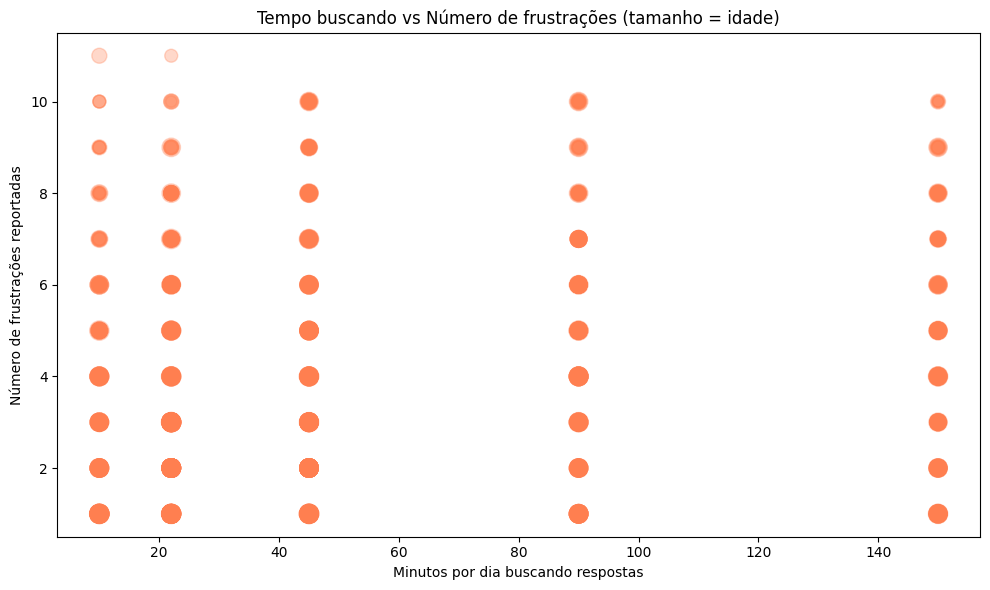

In [16]:
# Mapear TimeSearching para minutos
time_map = {
    'Less than 15 minutes a day': 10,
    '15-30 minutes a day': 22,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

QUERY = """
SELECT TimeSearching, Frustration, Age 
FROM main 
WHERE TimeSearching IS NOT NULL 
AND Frustration IS NOT NULL 
AND Age IS NOT NULL
"""
df_bubble = pd.read_sql_query(QUERY, conn)

# Converter texto para número
df_bubble['Age_num'] = df_bubble['Age'].map(age_map)
df_bubble['TimeSearching_num'] = df_bubble['TimeSearching'].map(time_map)

# Contar frustrações (cada respondente pode ter várias separadas por ;)
df_bubble['Frustration_num'] = df_bubble['Frustration'].str.split(';').str.len()

df_bubble = df_bubble.dropna()
print(f"Registros para plotar: {len(df_bubble)}")

plt.figure(figsize=(10, 6))
plt.scatter(
    df_bubble['TimeSearching_num'],
    df_bubble['Frustration_num'],
    s=df_bubble['Age_num'] * 3,
    alpha=0.3,
    color='coral'
)
plt.title('Tempo buscando vs Número de frustrações (tamanho = idade)')
plt.xlabel('Minutos por dia buscando respostas')
plt.ylabel('Número de frustrações reportadas')
plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


In [ ]:
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)

top_db = df_db['DatabaseWantToWorkWith'].str.split(';').explode().str.strip().value_counts().head(5)

plt.figure(figsize=(8, 8))
top_db.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Top 5 bancos de dados que desenvolvedores querem aprender')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


In [ ]:
QUERY = """
SELECT Age, TimeSearching, TimeAnswering
FROM main
WHERE Age IN ('25-34 years old', '35-44 years old')
AND TimeSearching IS NOT NULL
AND TimeAnswering IS NOT NULL
"""
df_stacked = pd.read_sql_query(QUERY, conn)
df_stacked['TimeSearching'] = pd.to_numeric(df_stacked['TimeSearching'], errors='coerce')
df_stacked['TimeAnswering'] = pd.to_numeric(df_stacked['TimeAnswering'], errors='coerce')

medians = df_stacked.groupby('Age')[['TimeSearching', 'TimeAnswering']].median()

medians.plot(kind='bar', stacked=True, figsize=(8, 5), color=['steelblue', 'coral'])
plt.title('Mediana de TimeSearching e TimeAnswering por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Tempo (minutos)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


In [ ]:
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
AND CompTotal IS NOT NULL
"""
df_line = pd.read_sql_query(QUERY, conn)
df_line['CompTotal'] = pd.to_numeric(df_line['CompTotal'], errors='coerce')

medians_age = df_line.groupby('Age')['CompTotal'].median()

plt.figure(figsize=(8, 5))
plt.plot(medians_age.index, medians_age.values, marker='o', color='steelblue')
plt.title('Mediana de CompTotal por faixa etária (45-60)')
plt.xlabel('Faixa etária')
plt.ylabel('Compensação total mediana')
plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


In [ ]:
QUERY = "SELECT MainBranch, COUNT(*) as count FROM main GROUP BY MainBranch ORDER BY count DESC"
df_branch = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))
plt.barh(df_branch['MainBranch'], df_branch['count'], color='steelblue')
plt.title('Distribuição por tipo de desenvolvedor')
plt.xlabel('Contagem')
plt.tight_layout()
plt.show()

In [ ]:
print("TimeSearching:")
print(df['TimeSearching'].value_counts().head(10))

print("\nFrustration:")
print(df['Frustration'].value_counts().head(10))

print("\nCompTotal:")
print(df['CompTotal'].value_counts().head(10))

In [ ]:
print(df.columns.tolist())

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
